# 06 — Prediction Pipeline (CNN Binary Classifier)

End-to-end inference on audio files:
1. Load audio
2. Extract mel spectrograms via a sliding 4-second window (2-second hop)
3. Run CNN inference per window
4. Majority vote → final environment label
5. Visualise confidence over time

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import librosa
import librosa.display

from src.cnn_classifier import CNNClassifier
from src.feature_extraction import sliding_window_mel
from src.utils import load_audio, plot_waveform

MODEL_PATH        = '../models/cnn_model.keras'
CUSTOM_TRANS_PATH = '../data/raw/transpotation'
CUSTOM_CONV_PATH  = '../data/raw/custom_audio/conversation'
SAMPLE_RATE       = 22050
WINDOW_SIZE       = 4.0   # seconds — must match training
HOP_SIZE          = 2.0   # seconds — 50% overlap
DEMO_DURATION     = 60.0  # seconds to load per demo file

COLORS = {'transportation': 'tomato', 'conversation': 'mediumseagreen', 'unknown': 'silver'}

## 1. Load CNN model

In [2]:
clf = CNNClassifier().load(MODEL_PATH)
print('CNN model loaded.')

CNN model loaded.


## 2. Inference helper

In [3]:
def predict_audio(audio_path, duration=DEMO_DURATION):
    """Run sliding-window CNN inference and return (labels, proba_conv, timestamps)."""
    audio, sr = load_audio(audio_path, sample_rate=SAMPLE_RATE, duration=duration)
    mel_list, timestamps = sliding_window_mel(
        audio, sample_rate=sr, window_size=WINDOW_SIZE, hop_size=HOP_SIZE
    )
    if not mel_list:
        return [], [], []
    X = np.array(mel_list)[..., np.newaxis]
    labels     = clf.predict_labels(X)
    proba_conv = clf.predict_proba(X)[:, 1]   # P(conversation)
    return labels, proba_conv, timestamps


def show_results(audio_path, labels, proba_conv, timestamps, title):
    """Print summary and plot confidence timeline."""
    from collections import Counter
    counts  = Counter(labels)
    total   = len(labels)
    dominant = counts.most_common(1)[0][0] if counts else 'unknown'
    conf     = counts[dominant] / total if total else 0

    print(f'File     : {os.path.basename(audio_path)}')
    print(f'Windows  : {total}  ({WINDOW_SIZE}s each, {HOP_SIZE}s hop)')
    print(f'Result   : {dominant.upper()}  ({conf:.0%} of windows agree)')
    print(f'Breakdown: {dict(counts)}')
    print()

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # Per-window bar: colour by predicted class
    bar_colors = [COLORS[l] for l in labels]
    axes[0].bar(timestamps, [1]*len(timestamps), width=HOP_SIZE*0.9,
                color=bar_colors, alpha=0.8, align='edge')
    legend_h = [mpatches.Patch(color=c, label=n.title())
                for n, c in COLORS.items() if n != 'unknown']
    axes[0].legend(handles=legend_h, loc='upper right')
    axes[0].set_title(title)
    axes[0].set_yticks([])

    # P(conversation) curve
    axes[1].fill_between(timestamps, proba_conv, alpha=0.35, color='mediumseagreen')
    axes[1].plot(timestamps, proba_conv, color='green', linewidth=1.5,
                 label='P(Conversation)')
    axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('P(conversation)')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

## 3. Demo — Transportation audio

File     : arunangshubanerjee-suburban-alley-traffic-ambience-359577.mp3
Windows  : 10  (4.0s each, 2.0s hop)
Result   : TRANSPORTATION  (100% of windows agree)
Breakdown: {'transportation': 10}



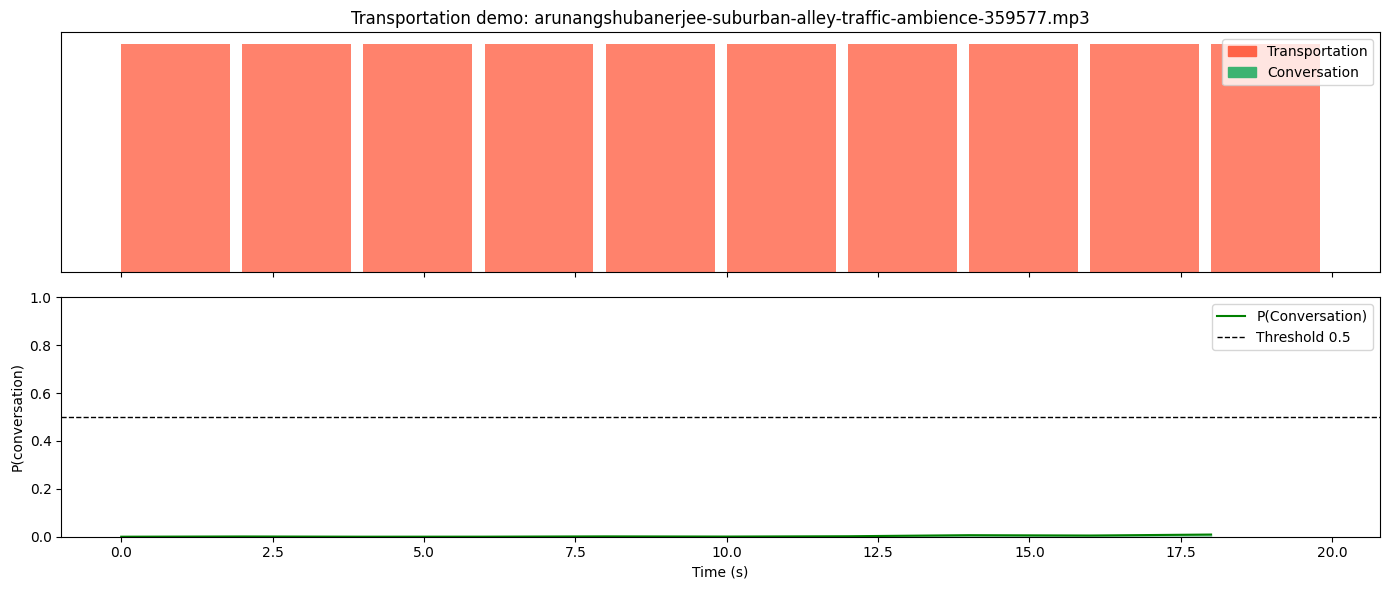

In [4]:
trans_files = sorted([
    f for f in os.listdir(CUSTOM_TRANS_PATH)
    if f.lower().endswith(('.mp3', '.wav', '.flac', '.ogg'))
])
trans_fp = os.path.join(CUSTOM_TRANS_PATH, trans_files[0])

labels_t, proba_t, ts_t = predict_audio(trans_fp)
show_results(trans_fp, labels_t, proba_t, ts_t,
             f'Transportation demo: {trans_files[0]}')

## 4. Demo — Conversation audio

File     : ES2008a.Mix-Headset.wav
Windows  : 29  (4.0s each, 2.0s hop)
Result   : CONVERSATION  (100% of windows agree)
Breakdown: {'conversation': 29}



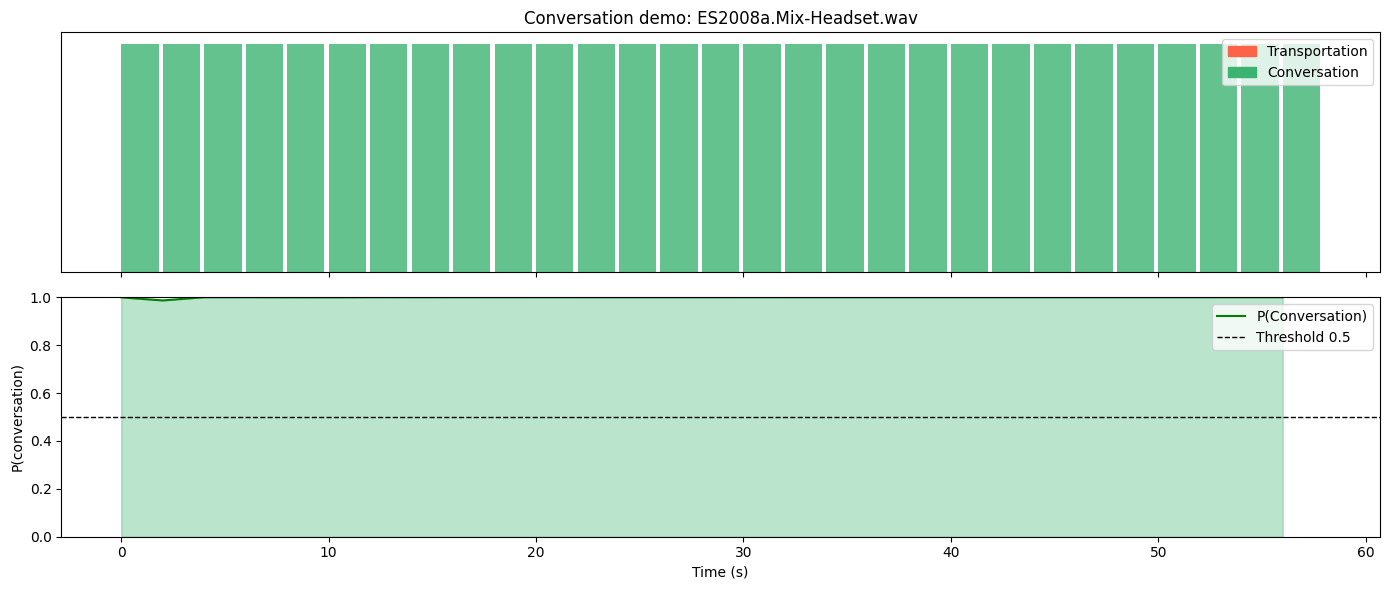

In [5]:
conv_files = sorted([
    f for f in os.listdir(CUSTOM_CONV_PATH)
    if f.lower().endswith(('.mp3', '.wav', '.flac', '.ogg'))
])
conv_fp = os.path.join(CUSTOM_CONV_PATH, conv_files[0])

labels_c, proba_c, ts_c = predict_audio(conv_fp)
show_results(conv_fp, labels_c, proba_c, ts_c,
             f'Conversation demo: {conv_files[0]}')

## 5. Using EnvironmentRecognizer (production API)

The `EnvironmentRecognizer` class wraps the CNN and provides the same interface
used by the hearing-impaired assistive app.

In [6]:
from src.recognizer import EnvironmentRecognizer

rec = EnvironmentRecognizer()

for fp, expected in [(trans_fp, 'transportation'), (conv_fp, 'conversation')]:
    result = rec.predict_file(fp, duration=DEMO_DURATION)
    status = '✓' if result['environment'] == expected else '✗'
    print(f'{status}  {os.path.basename(fp)}')
    print(f'   Predicted : {result["label"]}  ({result["confidence"]:.0%})')
    print(f'   Alert     : {result["alert_sound"]}')
    print()

✓  arunangshubanerjee-suburban-alley-traffic-ambience-359577.mp3
   Predicted : Transportation Mode  (100%)
   Alert     : transportation

✓  ES2008a.Mix-Headset.wav
   Predicted : Conversation Mode  (100%)
   Alert     : None

